# EDA v5 - Visual notebook
Source: `Database - Testcase_agentic_ai_V1.0.zip.csv`

Picks up from script versions v1-v4. This notebook adds histograms, boxplots, correlation matrices and time/factory views.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

CSV = r'C:\Users\tmiha\Documents\Touchpulse\Assignment\Database - Testcase_agentic_ai_V1.0.zip.csv'
df = pd.read_csv(CSV, sep=';', decimal=',', dayfirst=True, parse_dates=['time'])

# Derived columns
df['CpuMHz_num'] = df['CpuMHz'].astype(str).str.split().str[0].astype(float)
df['CpuMHz_is_composite'] = df['CpuMHz'].astype(str).str.contains(' ')
df['LoadPct'] = 100 * df['AvgValue'] / df['CpuMHz_num']
df['Range'] = df['MaxValue'] - df['MinValue']
df['dow'] = df['time'].dt.day_name()

df.shape, df.dtypes

((220294, 13),
 IPC                            object
 Data Factory                    int64
 time                   datetime64[ns]
 AvgValue                      float64
 MinValue                      float64
 MaxValue                      float64
 MetricId                       object
 CpuMHz                         object
 CpuMHz_num                    float64
 CpuMHz_is_composite              bool
 LoadPct                       float64
 Range                         float64
 dow                            object
 dtype: object)

## 1. Quick recap

In [2]:
summary = pd.DataFrame({
    'rows': [len(df)],
    'unique_IPC': [df['IPC'].nunique()],
    'unique_Factory': [df['Data Factory'].nunique()],
    'unique_CpuMHz': [df['CpuMHz'].nunique()],
    'date_min': [df['time'].min()],
    'date_max': [df['time'].max()],
    'days_in_window': [(df['time'].max()-df['time'].min()).days+1],
    'missing_total': [df.isna().sum().sum()],
    'duplicated_rows': [df.duplicated().sum()],
})
summary.T

,0
rows,220294
unique_IPC,4261
unique_Factory,5
unique_CpuMHz,66
date_min,2021-05-01 00:00:00
date_max,2021-06-30 00:00:00
days_in_window,61
missing_total,0
duplicated_rows,0


## 2. Histograms of numeric columns (raw + log)

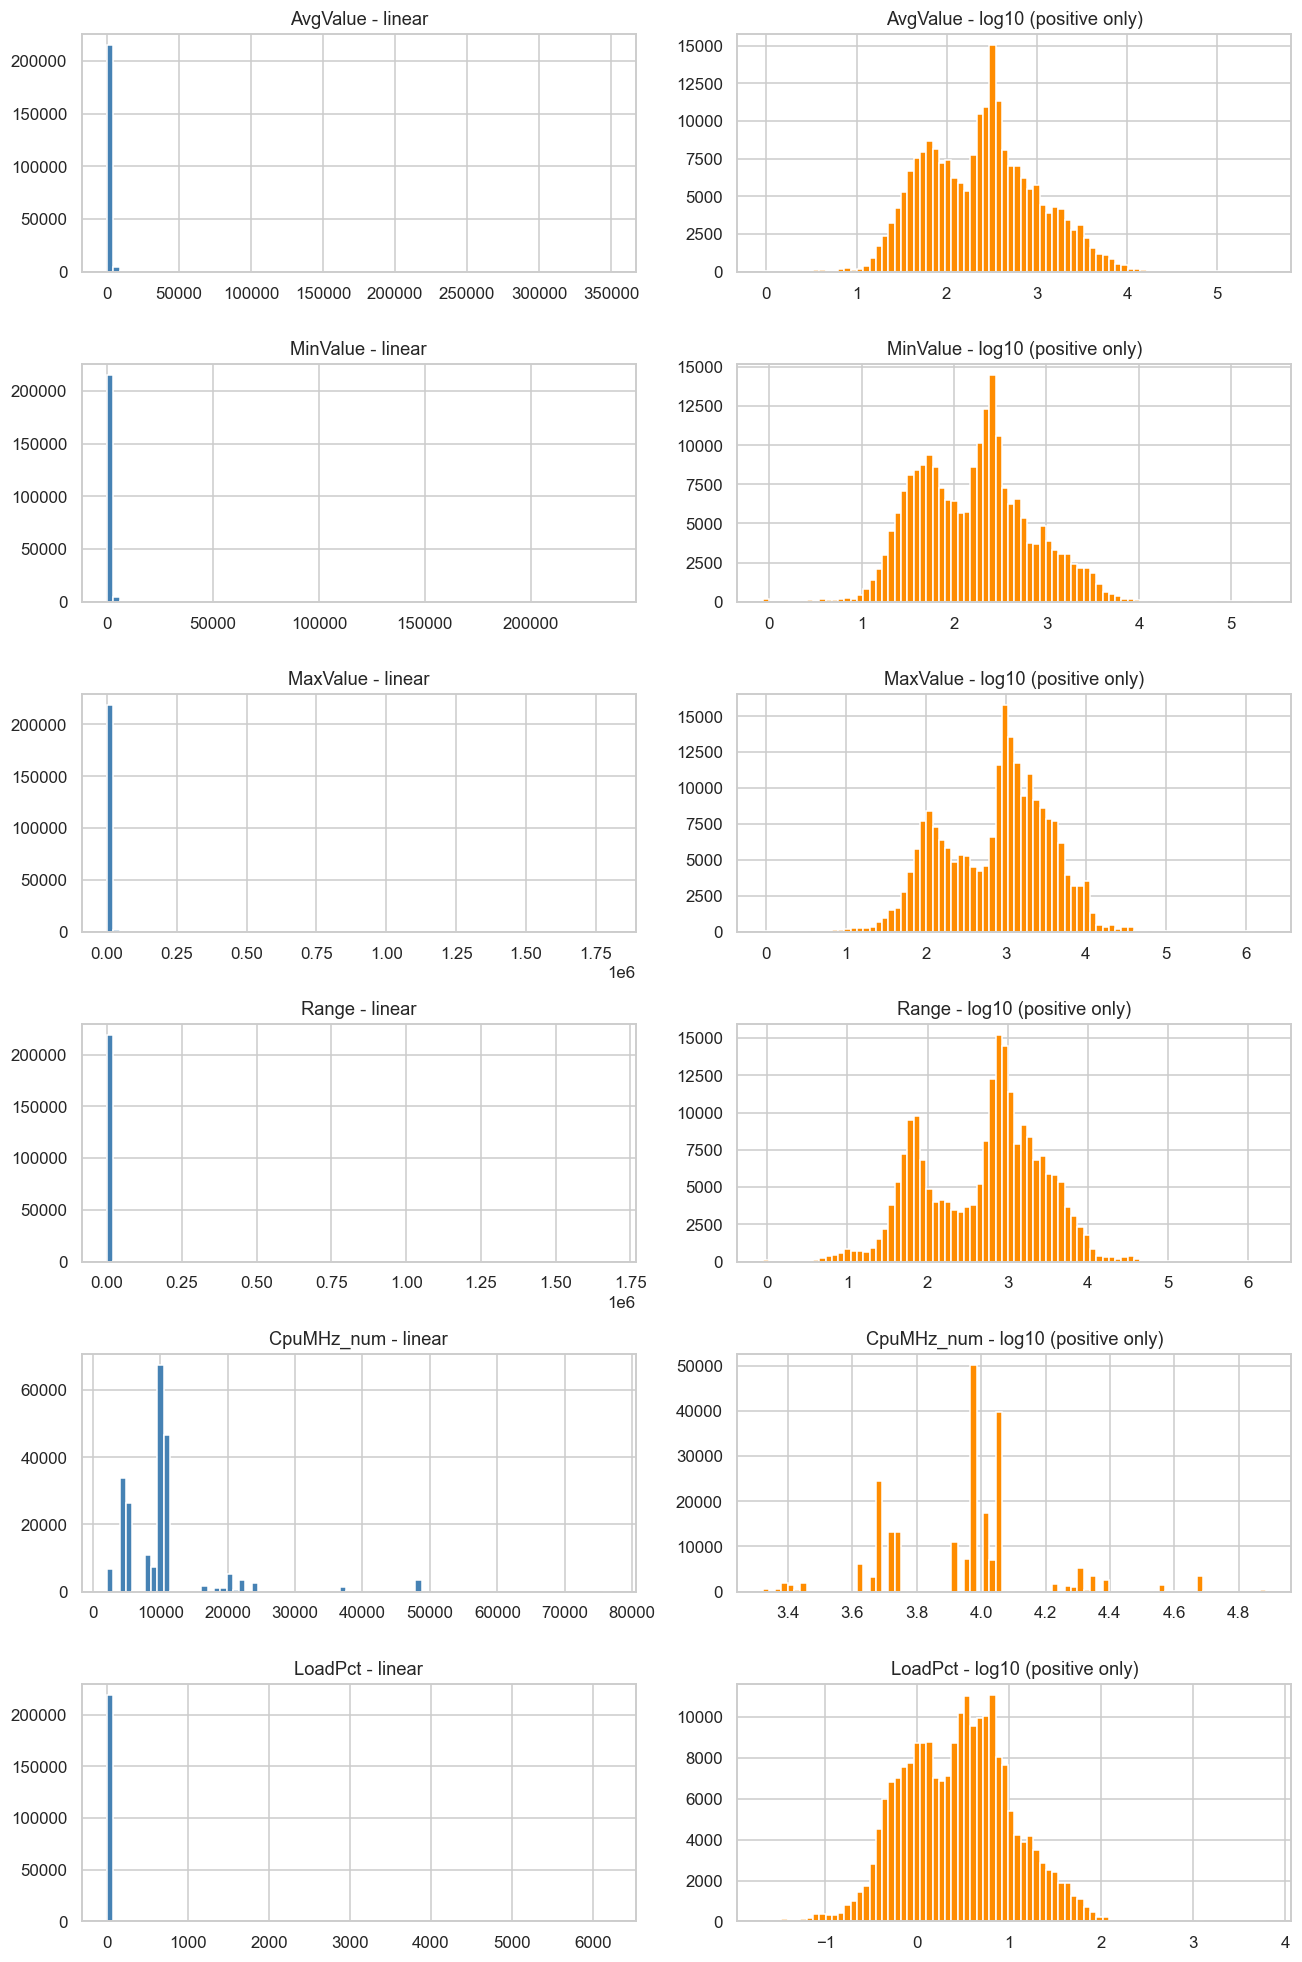

In [3]:
num_cols = ['AvgValue', 'MinValue', 'MaxValue', 'Range', 'CpuMHz_num', 'LoadPct']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3*len(num_cols)))
for i, c in enumerate(num_cols):
    s = df[c].dropna()
    axes[i,0].hist(s, bins=80, color='steelblue')
    axes[i,0].set_title(f'{c} - linear')
    pos = s[s > 0]
    axes[i,1].hist(np.log10(pos), bins=80, color='darkorange')
    axes[i,1].set_title(f'{c} - log10 (positive only)')
plt.tight_layout(); plt.show()

## 3. Boxplots: AvgValue by Data Factory (raw + log)

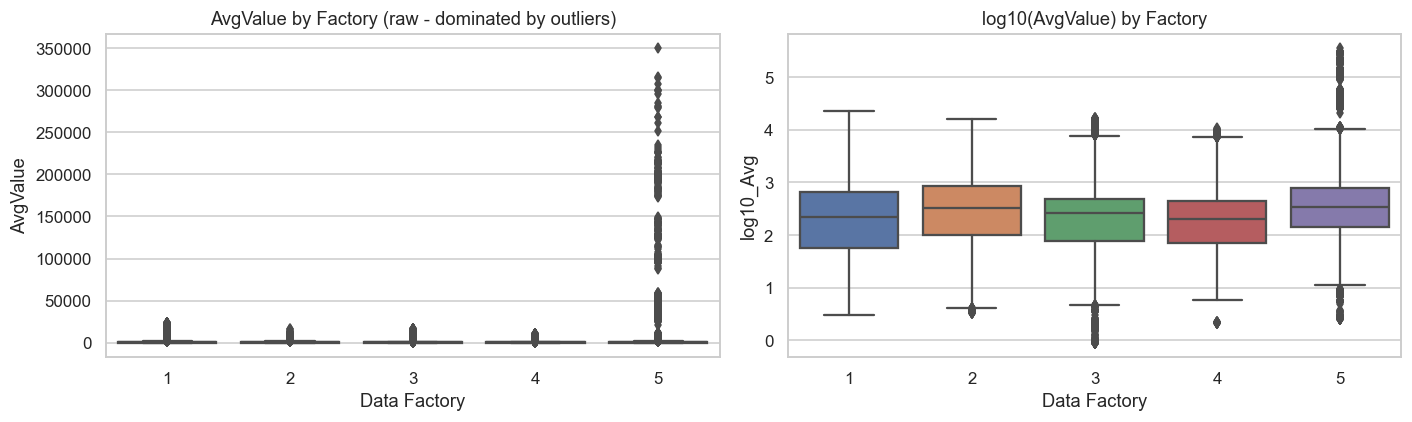

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.boxplot(data=df, x='Data Factory', y='AvgValue', ax=axes[0])
axes[0].set_title('AvgValue by Factory (raw - dominated by outliers)')
tmp = df[df['AvgValue']>0].copy(); tmp['log10_Avg']=np.log10(tmp['AvgValue'])
sns.boxplot(data=tmp, x='Data Factory', y='log10_Avg', ax=axes[1])
axes[1].set_title('log10(AvgValue) by Factory')
plt.tight_layout(); plt.show()

## 4. Correlation matrix
Pearson on raw values, plus Spearman (rank) which is robust to the heavy right tail.

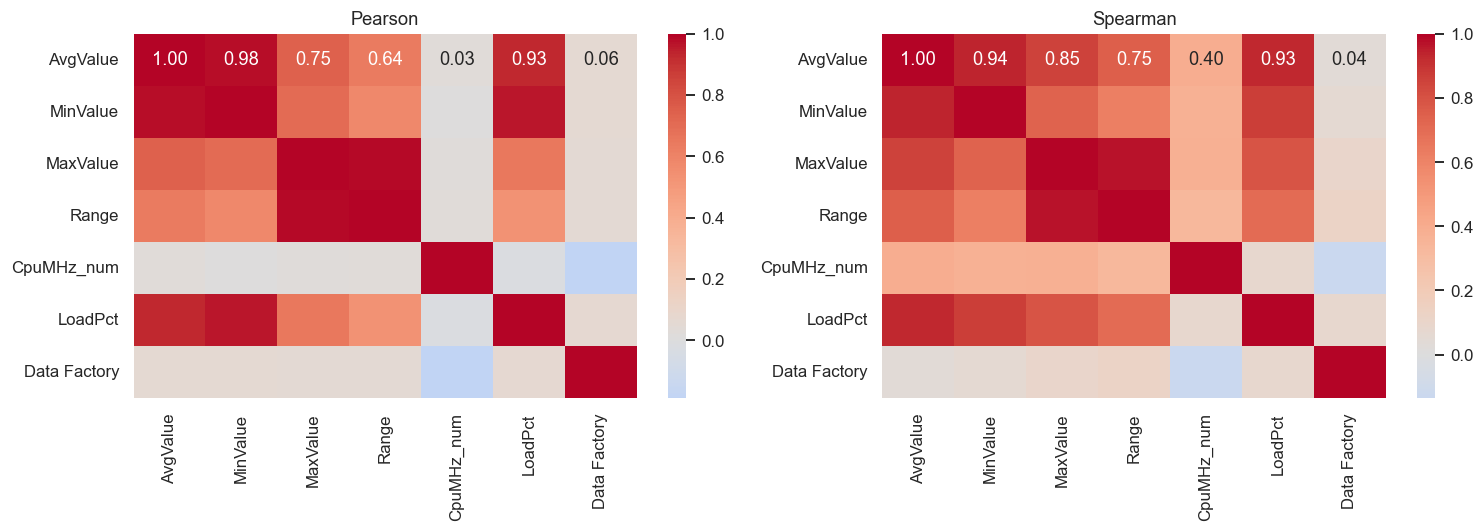

In [5]:
corr_cols = ['AvgValue','MinValue','MaxValue','Range','CpuMHz_num','LoadPct','Data Factory']
pear = df[corr_cols].corr(method='pearson')
spear = df[corr_cols].corr(method='spearman')
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.heatmap(pear, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0]); axes[0].set_title('Pearson')
sns.heatmap(spear, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1]); axes[1].set_title('Spearman')
plt.tight_layout(); plt.show()

## 5. Pairwise scatter (sampled, log-scaled)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

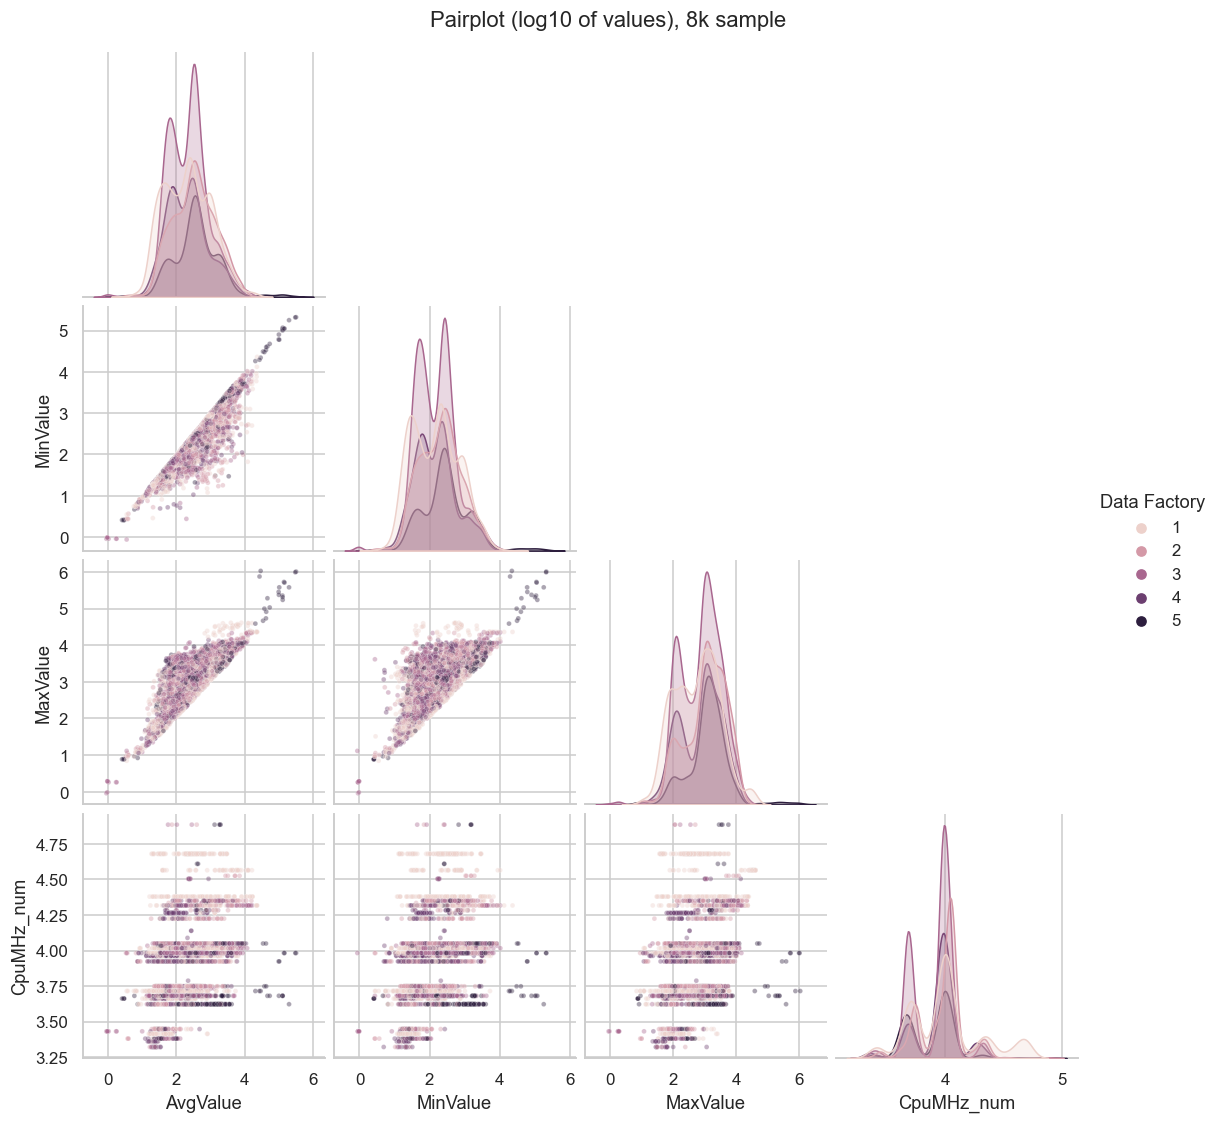

In [6]:
samp = df.sample(min(8000, len(df)), random_state=0)
samp_pos = samp[(samp['AvgValue']>0)&(samp['MinValue']>0)&(samp['MaxValue']>0)].copy()
for c in ['AvgValue','MinValue','MaxValue','CpuMHz_num']:
    samp_pos[c] = np.log10(samp_pos[c])
g = sns.pairplot(samp_pos[['AvgValue','MinValue','MaxValue','CpuMHz_num','Data Factory']],
                 hue='Data Factory', plot_kws={'alpha':0.4,'s':10}, corner=True)
g.fig.suptitle('Pairplot (log10 of values), 8k sample', y=1.02); plt.show()

## 6. Time-series view

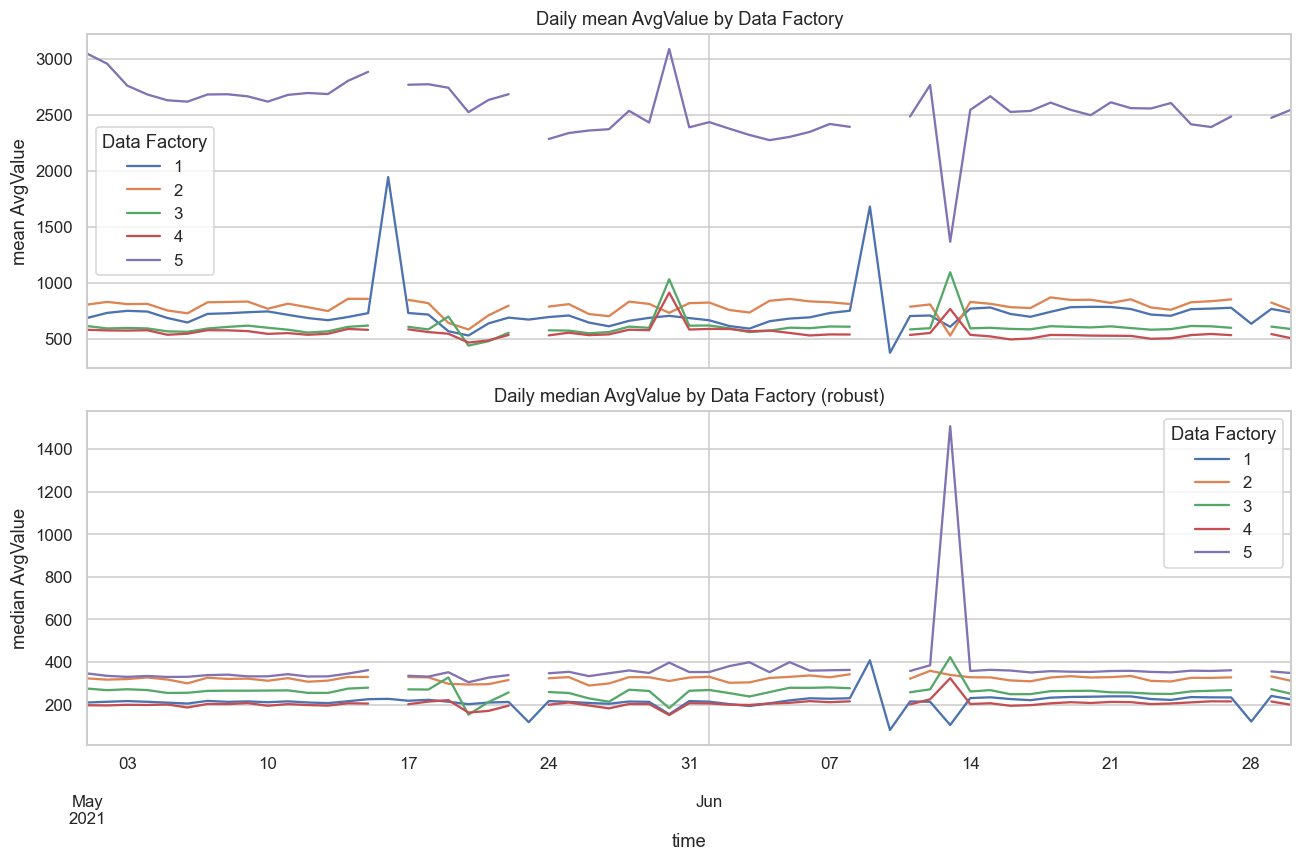

In [7]:
daily = df.groupby(['time','Data Factory'])['AvgValue'].mean().unstack()
fig, axes = plt.subplots(2,1, figsize=(12,8), sharex=True)
daily.plot(ax=axes[0]); axes[0].set_title('Daily mean AvgValue by Data Factory'); axes[0].set_ylabel('mean AvgValue')
daily_med = df.groupby(['time','Data Factory'])['AvgValue'].median().unstack()
daily_med.plot(ax=axes[1]); axes[1].set_title('Daily median AvgValue by Data Factory (robust)'); axes[1].set_ylabel('median AvgValue')
plt.tight_layout(); plt.show()

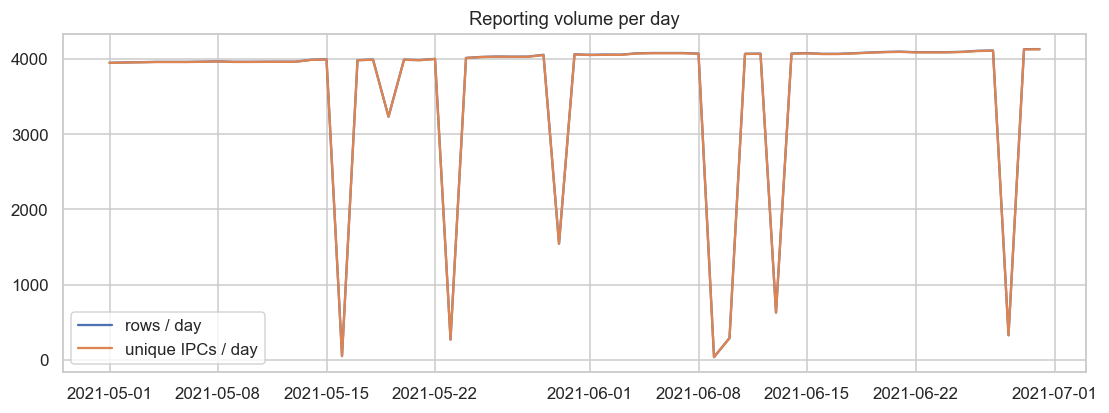

In [8]:
rec_cnt = df.groupby('time').size()
ipc_cnt = df.groupby('time')['IPC'].nunique()
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(rec_cnt.index, rec_cnt.values, label='rows / day')
ax.plot(ipc_cnt.index, ipc_cnt.values, label='unique IPCs / day')
ax.set_title('Reporting volume per day'); ax.legend(); plt.show()

## 7. Weekday pattern

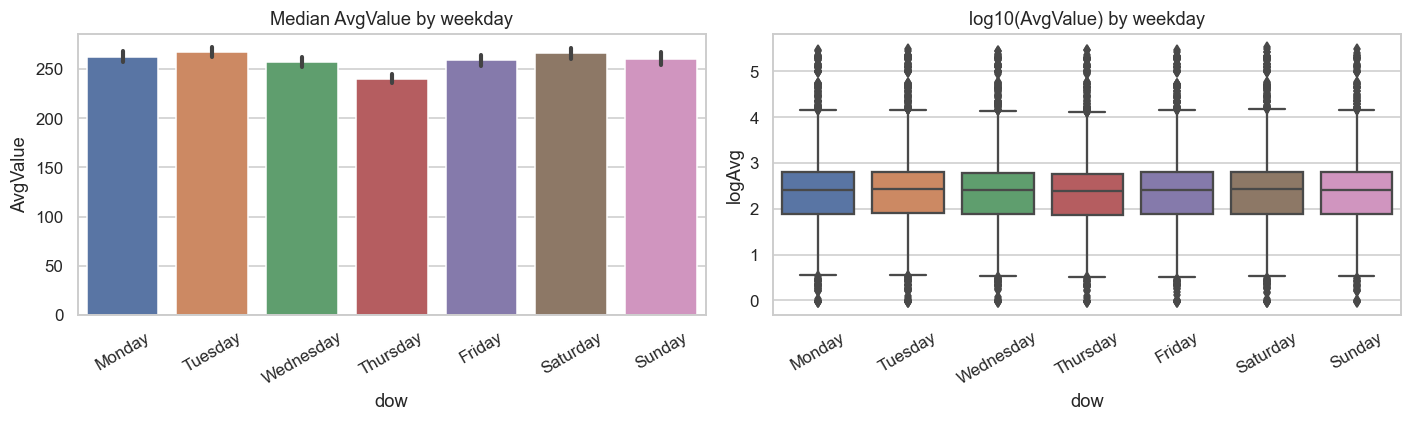

In [9]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, axes = plt.subplots(1,2, figsize=(13,4))
sns.barplot(data=df, x='dow', y='AvgValue', estimator='median', order=order, ax=axes[0])
axes[0].set_title('Median AvgValue by weekday'); axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df[df['AvgValue']>0].assign(logAvg=lambda d: np.log10(d['AvgValue'])),
            x='dow', y='logAvg', order=order, ax=axes[1])
axes[1].set_title('log10(AvgValue) by weekday'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 8. CpuMHz distribution and Load%

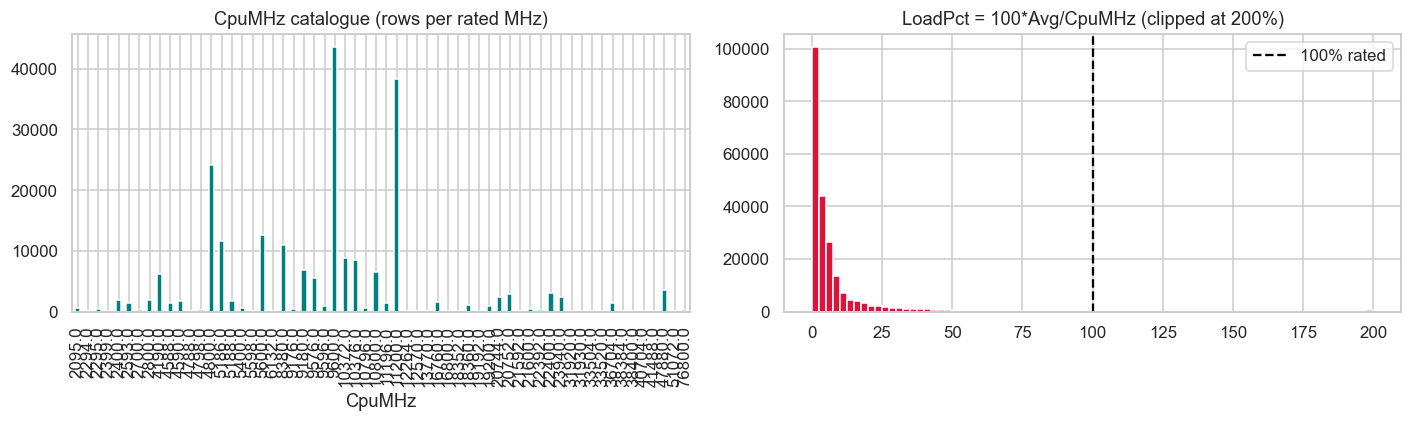

In [10]:
fig, axes = plt.subplots(1,2, figsize=(13,4))
df['CpuMHz_num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('CpuMHz catalogue (rows per rated MHz)'); axes[0].set_xlabel('CpuMHz')
axes[0].tick_params(axis='x', rotation=90)
lp = df['LoadPct'].clip(upper=200)
axes[1].hist(lp, bins=80, color='crimson')
axes[1].axvline(100, color='black', linestyle='--', label='100% rated')
axes[1].set_title('LoadPct = 100*Avg/CpuMHz (clipped at 200%)'); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. Top noisy IPCs

In [11]:
ipc_stats = df.groupby('IPC').agg(
    mean_avg=('AvgValue','mean'),
    max_avg=('AvgValue','max'),
    std_avg=('AvgValue','std'),
    n=('AvgValue','size'),
    factory=('Data Factory','first'),
    cpu=('CpuMHz_num','first'),
).assign(load=lambda d: 100*d['mean_avg']/d['cpu'])
print('Top 15 IPCs by max AvgValue:')
display(ipc_stats.sort_values('max_avg', ascending=False).head(15))
print('Top 15 IPCs by mean LoadPct:')
display(ipc_stats.sort_values('load', ascending=False).head(15))

Top 15 IPCs by max AvgValue:


,mean_avg,max_avg,std_avg,n,factory,cpu,load
IPC,,,,,,,
ITLT1593,220749.230817,349703.58950,48728.801505,54,5,9600.0,2299.471154
ITLT3031,205886.638082,260560.81510,13444.791562,55,5,4190.0,4913.762245
ITLT3258,127133.837899,196204.54540,14473.150910,53,5,4800.0,2648.621623
ITLT4698,143617.417724,149677.10020,3658.299916,21,5,9600.0,1496.014768
ITLT3993,100251.923519,113292.89630,4731.896266,54,5,8380.0,1196.323670
ITLT3617,52107.633876,59187.19594,3529.376329,53,5,4800.0,1085.575706
ITLT1430,49374.629107,55234.51059,3741.503285,8,5,4798.0,1029.066884
ITLT2624,42961.375889,48919.03279,3774.039643,55,5,5600.0,767.167427
ITLT2552,39018.097763,43461.77362,3119.031442,15,5,11200.0,348.375873


Top 15 IPCs by mean LoadPct:


,mean_avg,max_avg,std_avg,n,factory,cpu,load
IPC,,,,,,,
ITLT3031,205886.638082,260560.815100,13444.791562,55,5,4190.0,4913.762245
ITLT3258,127133.837899,196204.545400,14473.150910,53,5,4800.0,2648.621623
ITLT1593,220749.230817,349703.589500,48728.801505,54,5,9600.0,2299.471154
ITLT4698,143617.417724,149677.100200,3658.299916,21,5,9600.0,1496.014768
ITLT3993,100251.923519,113292.896300,4731.896266,54,5,8380.0,1196.323670
ITLT3617,52107.633876,59187.195940,3529.376329,53,5,4800.0,1085.575706
ITLT1430,49374.629107,55234.510590,3741.503285,8,5,4798.0,1029.066884
ITLT2624,42961.375889,48919.032790,3774.039643,55,5,5600.0,767.167427
ITLT2279,28697.061519,33595.051610,2433.722775,55,5,5186.0,553.356373


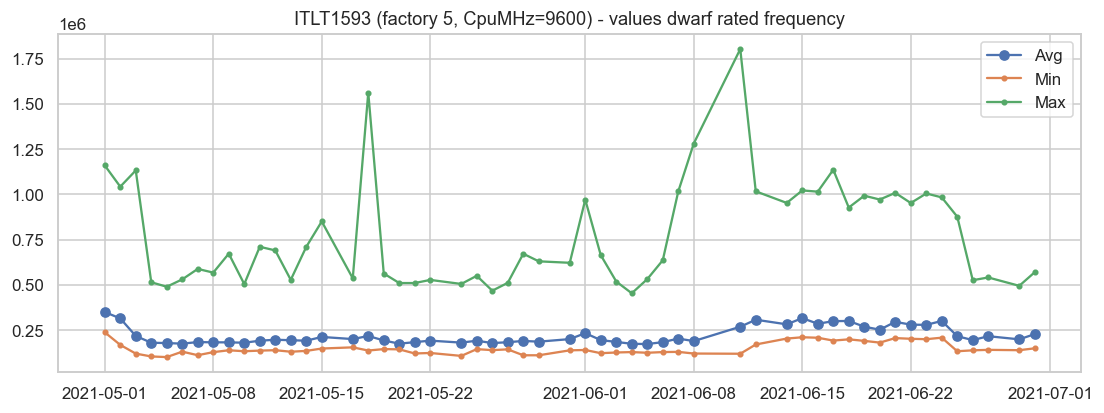

In [12]:
# Highlight the suspect IPC ITLT1593 over time
suspect = df[df['IPC']=='ITLT1593'].sort_values('time')
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(suspect['time'], suspect['AvgValue'], marker='o', label='Avg')
ax.plot(suspect['time'], suspect['MinValue'], marker='.', label='Min')
ax.plot(suspect['time'], suspect['MaxValue'], marker='.', label='Max')
ax.set_title('ITLT1593 (factory 5, CpuMHz=9600) - values dwarf rated frequency')
ax.legend(); plt.show()

## 10. Takeaways
- Numeric columns are heavily right-skewed; use log scales or robust statistics for modelling.
- AvgValue, MinValue, MaxValue are nearly collinear (Spearman ~ 0.9+) - consider dropping Min/Max or replacing with `Range`.
- Factory 5 carries extreme outliers driven mostly by IPC ITLT1593 (avg 300k MHz vs 9600 rated). Treat as data error before training.
- 261 composite CpuMHz strings need a real parsing rule (sum? max? per-CPU rows?).
- IPCs are mostly partial (median 54/61 days) - irregular time series, prefer aggregations or padding.
- Single MetricId column is constant and can be dropped.